In [1]:
import pandas as pd

df = pd.read_csv("airline-passengers.csv",
                 parse_dates=['Month'],
                 index_col='Month')

df.head()

,Passengers
Month,
1949-01,112.0
1949-02,118.0
1949-03,132.0
...,NaN


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

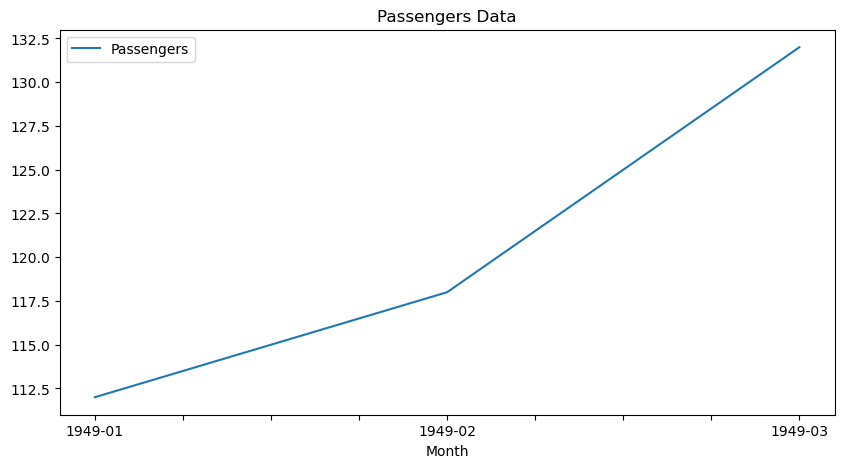

In [4]:
df.plot(figsize=(10,5), title="Passengers Data")
plt.show()

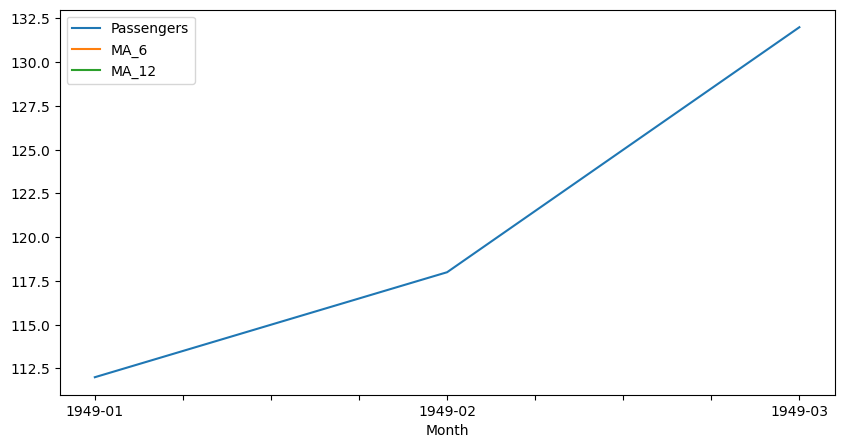

In [5]:
df['MA_6'] = df['Passengers'].rolling(6).mean()
df['MA_12'] = df['Passengers'].rolling(12).mean()

df[['Passengers','MA_6','MA_12']].plot(figsize=(10,5))
plt.show()

In [6]:
train = df.iloc[:-12]
test = df.iloc[-12:]

In [9]:
print(df.shape)
print(df.head())
print(df.columns)

(4, 3)
         Passengers  MA_6  MA_12
Month                           
1949-01       112.0   NaN    NaN
1949-02       118.0   NaN    NaN
1949-03       132.0   NaN    NaN
...             NaN   NaN    NaN
Index(['Passengers', 'MA_6', 'MA_12'], dtype='object')


In [11]:
df = df[['Passengers']]

In [13]:
df = pd.read_csv("airline-passengers.csv")

# Convert Month column properly
df['Month'] = pd.to_datetime(df['Month'], format='%Y-%m', errors='coerce')

# Drop wrong rows (if any)
df = df.dropna()

# Set index
df.set_index('Month', inplace=True)

# Set frequency
df = df.asfreq('MS')

df.head()

,Passengers
Month,
1949-01-01,112.0
1949-02-01,118.0
1949-03-01,132.0


In [15]:
print(df.columns)

Index(['Passengers'], dtype='object')


In [18]:
import pandas as pd

df = pd.read_csv("airline-passengers.csv")

# Clean column names
df.columns = df.columns.str.strip()

print("Columns:", df.columns)

# If Month exists → use it
if 'Month' in df.columns:
    df['Month'] = pd.to_datetime(df['Month'], errors='coerce')
    df.set_index('Month', inplace=True)

# Else assume first column is date
else:
    df.iloc[:,0] = pd.to_datetime(df.iloc[:,0], errors='coerce')
    df.set_index(df.columns[0], inplace=True)

# Keep only Passengers
df = df[['Passengers']]

# Set frequency
df = df.asfreq('MS')

print(df.head())
print(df.shape)

Columns: Index(['Month', 'Passengers'], dtype='object')
            Passengers
Month                 
1949-01-01       112.0
1949-02-01       118.0
1949-03-01       132.0
(3, 1)


NameError: name 'forecast' is not defined

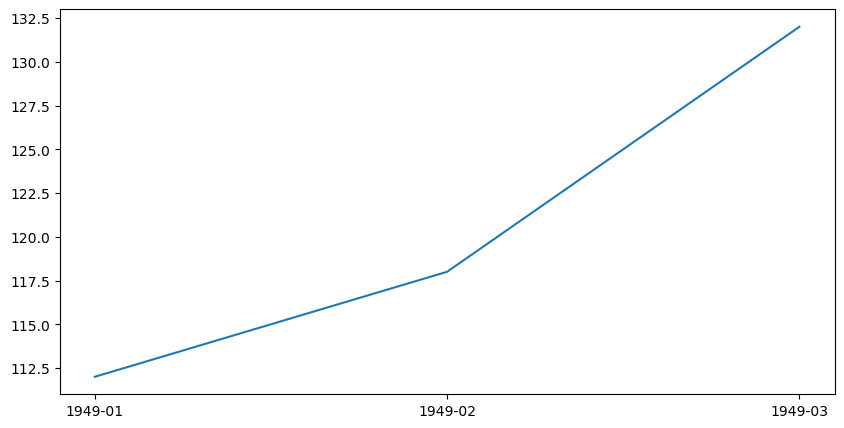

In [19]:
plt.figure(figsize=(10,5))
plt.plot(test.index, test, label='Actual')
plt.plot(test.index, forecast, label='Forecast')
plt.legend()
plt.show()

In [21]:
!pip install statsmodels

Defaulting to user installation because normal site-packages is not writeable


In [22]:
plt.show()